In [1]:
import pandas as pd
import numpy as np
import cv2
import os # to accsses folders
import matplotlib.pyplot as plt
import seaborn as sns

# encoding , scaling
from sklearn.preprocessing import StandardScaler, label_binarize

# models
from sklearn.cluster import KMeans

# evaluation
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, mean_squared_error,roc_curve, roc_auc_score


In [3]:
# import kagglehub
# path = kagglehub.dataset_download("iarunava/cell-images-for-detecting-malaria")

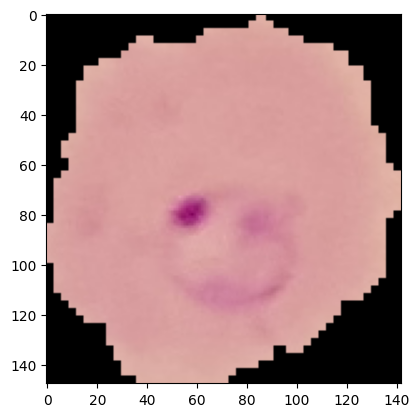

In [4]:
img = cv2.imread(r"C:\Users\dohah\Documents\Projects\Detecting Malaria Model\MachineLearningProject\img_dataset\Parasitized_sample.png")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()


In [5]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


In [7]:
# from google.colab import drive
# drive.mount('/content/drive')

In [8]:
blur = cv2.GaussianBlur(gray, (5,5), 0)


In [9]:
norm = cv2.normalize(blur, None, 0, 255, cv2.NORM_MINMAX)


In [10]:
Z = gray.reshape((-1,1))
Z = np.float32(Z)

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
K = 2  # infected / non-infected pixels
ret, label, center = cv2.kmeans(Z, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

center = np.uint8(center)
segmented = center[label.flatten()]
segmented_img = segmented.reshape(gray.shape)


In [11]:
ret, thresh = cv2.threshold(segmented_img, 0, 255, cv2.THRESH_OTSU)


In [12]:
kernel = np.ones((3,3), np.uint8)
clean = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)


In [13]:
contours, _ = cv2.findContours(clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

features = []
features.append(len(contours))        # number of parasites
if len(contours) > 0:
    features.append(cv2.contourArea(contours[0]))
else:
    features.append(0)


In [14]:
!pip install tqdm

Defaulting to user installation because normal site-packages is not writeable


You should consider upgrading via the 'D:\programming\python\python-3.10.0\python.exe -m pip install --upgrade pip' command.
